# 03 - Feature Engineering Before Model Training

Purpose: inspect the gold feature store before model training.

In [5]:
from pathlib import Path
import json
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark
from pyspark.sql import SparkSession, functions as F, Window

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
DATAMART_DIR = PROJECT_ROOT / "datamart"
MODEL_BANK_DIR = PROJECT_ROOT / "outputs" / "model_bank"
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"

def spark_path(path):
    return Path(path).resolve().as_posix()

spark = (pyspark.sql.SparkSession.builder
         .appName("assignment_2_notebook")
         .master("local[*]")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

print(f"Project root: {PROJECT_ROOT}")
print(f"Spark version: {spark.version}")

Project root: /opt/airflow/project
Spark version: 3.5.1


In [6]:
feature_store_path = DATAMART_DIR / "gold" / "feature_store"
feature_store = spark.read.parquet(spark_path(feature_store_path))
print(f"Feature store rows: {feature_store.count():,}")
print(f"Feature store columns: {len(feature_store.columns):,}")
feature_store.printSchema()
display(feature_store.limit(5).toPandas())

Feature store rows: 8,974
Feature store columns: 51
root
 |-- Customer_ID: string (nullable = true)
 |-- feature_snapshot_date: date (nullable = true)
 |-- label_snapshot_date: date (nullable = true)
 |-- Num_Bank_Accounts: double (nullable = true)
 |-- Num_Credit_Card: double (nullable = true)
 |-- Interest_Rate: double (nullable = true)
 |-- Num_of_Loan: double (nullable = true)
 |-- Delay_from_due_date: double (nullable = true)
 |-- Num_of_Delayed_Payment: double (nullable = true)
 |-- Changed_Credit_Limit: double (nullable = true)
 |-- Num_Credit_Inquiries: double (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Credit_Utilization_Ratio: double (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Payment_Behaviour: string (nullable = true)
 |-- Monthly_Balance: double (nullable = true)
 |-- credit_history_months: double (nullable = true)
 |-- num_loan_types: integer (nullable = true)
 |-- log_Annual_Income: double (nullable = true)
 |-- debt_t

,Customer_ID,feature_snapshot_date,label_snapshot_date,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
0,CUS_0x3873,2023-01-01,2023-07-01,1.0,3.0,11.0,2.0,15.0,12.0,5.41,...,51.0,312.0,194.0,90.0,164.0,173.0,24.0,107.0,37.0,86.0
1,CUS_0xa146,2023-01-01,2023-07-01,5.0,6.0,17.0,3.0,6.0,19.0,7.45,...,-112.0,248.0,95.0,-48.0,208.0,-82.0,211.0,193.0,58.0,109.0
2,CUS_0x3061,2023-02-01,2023-08-01,5.0,7.0,32.0,6.0,28.0,21.0,8.42,...,-26.0,-9.0,9.0,190.0,84.0,-19.0,51.0,189.0,221.0,17.0
3,CUS_0x8afa,2023-02-01,2023-08-01,7.0,10.0,18.0,8.0,60.0,22.0,17.81,...,135.0,-64.0,-77.0,-76.0,119.0,107.0,118.0,196.0,73.0,167.0
4,CUS_0x2da6,2023-03-01,2023-09-01,7.0,5.0,13.0,1.0,23.0,19.0,12.12,...,53.0,133.0,33.0,184.0,205.0,159.0,17.0,104.0,17.0,-86.0


In [7]:
id_columns = {"Customer_ID", "loan_id", "label", "label_def", "feature_snapshot_date", "label_snapshot_date"}
feature_columns = [col for col in feature_store.columns if col not in id_columns]
numeric_types = {"int", "bigint", "double", "float", "decimal", "long", "short"}
schema_types = dict(feature_store.dtypes)
numeric_features = [col for col in feature_columns if schema_types[col].split("(")[0] in numeric_types]
categorical_features = [col for col in feature_columns if col not in numeric_features]

print(f"Model feature count: {len(feature_columns)}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(categorical_features)

Model feature count: 45
Numeric features: 40
Categorical features: 5
['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Occupation', 'Age_group']


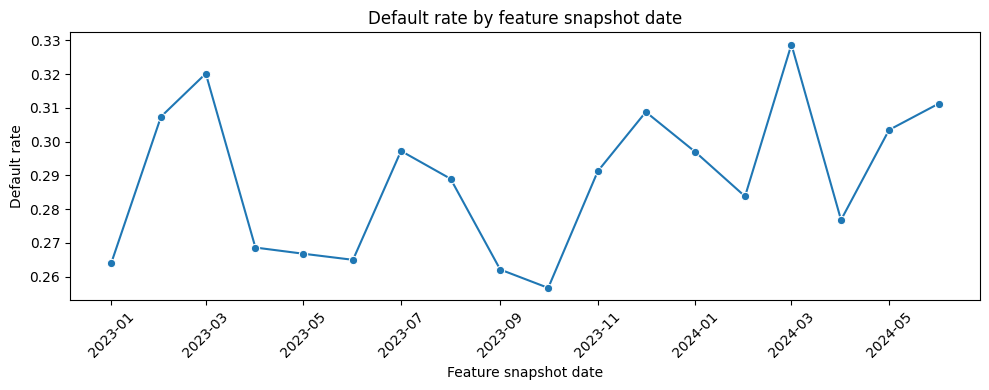

In [8]:
label_profile = (feature_store.groupBy("feature_snapshot_date")
                 .agg(F.count("*").alias("row_count"),F.avg("label").alias("default_rate"))
                 .orderBy("feature_snapshot_date").toPandas())

fig, ax1 = plt.subplots(figsize=(10, 4))
sns.lineplot(data=label_profile, x="feature_snapshot_date", y="default_rate", marker="o", ax=ax1)
ax1.set_title("Default rate by feature snapshot date")
ax1.set_xlabel("Feature snapshot date")
ax1.set_ylabel("Default rate")
plt.xticks(rotation=45)
plt.tight_layout()

In [9]:
missing_exprs = [F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in feature_columns]
missing = feature_store.select(missing_exprs).toPandas().T.reset_index()
missing.columns = ["feature_name", "missing_count"]
missing["missing_rate"] = missing["missing_count"] / feature_store.count()
display(missing.sort_values("missing_rate", ascending=False).head(20))

,feature_name,missing_count,missing_rate
22,Age,701,0.078115
23,Occupation,0,0.000000
25,fe_1,0,0.000000
26,fe_2,0,0.000000
27,fe_3,0,0.000000
28,fe_4,0,0.000000
29,fe_5,0,0.000000
30,fe_6,0,0.000000
31,fe_7,0,0.000000
32,fe_8,0,0.000000


In [11]:
numeric_summary = feature_store.select(numeric_features).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")
display(numeric_summary.toPandas())

,summary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Utilization_Ratio,...,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
0,count,8974,8974,8974,8974,8974,8974,8974,8974,8974,...,8974,8974,8974,8974,8974,8974,8974,8974,8974,8974
1,mean,5.413527969690216,5.655449075105861,14.843325161577893,3.1046356139959883,21.021283708491197,13.291063071094273,10.13007020280808,6.663917985290841,32.34211211228277,...,100.36550033429909,99.8038778694005,101.76275908179184,98.62168486739469,99.80532649877424,99.32883886784043,100.62023623802095,102.88600401158904,98.87541787385781,98.35190550479162
2,stddev,2.6348062803791366,2.149869268966417,8.95675877901071,64.92404734173425,14.91597228551652,6.178803721639605,6.8917474545539905,3.945245106246286,5.152090633465818,...,99.63471629997692,99.93594896523064,100.86931181918877,100.81805956538018,101.00285114554418,101.04295231249449,101.05903932282935,102.04709579712079,102.79465221245555,105.3355777444227
3,min,-1.0,0.0,1.0,-100.0,-5.0,-3.0,-6.49,0.0,20.10076996070649,...,-298.0,-289.0,-248.0,-293.0,-271.0,-277.0,-309.0,-299.0,-278.0,-313.0
4,25%,3.0,4.0,8.0,1.0,10.0,9.0,4.94,4.0,28.050828603885414,...,34.0,33.0,34.0,33.0,33.0,30.0,33.0,33.0,30.0,27.0
5,50%,6.0,6.0,13.0,3.0,18.0,14.0,9.22,6.0,32.4013515398934,...,100.0,101.0,103.0,100.0,100.0,99.0,101.0,104.0,99.0,98.0
6,75%,7.0,7.0,20.0,5.0,28.0,18.0,14.56,10.0,36.60865463247785,...,167.0,168.0,170.0,165.0,168.0,168.0,168.0,174.0,168.0,168.0
7,max,10.0,10.0,32.0,1495.0,67.0,23.0,36.97,14.0,48.19982397892475,...,493.0,490.0,485.0,494.0,452.0,498.0,493.0,474.0,500.0,510.0


In [12]:
for col in categorical_features:
    print(f"\n{col}")
    display(feature_store.groupBy(col).count().orderBy(F.desc("count")).limit(10).toPandas())


Credit_Mix


,Credit_Mix,count
0,Standard,3203
1,Good,2186
2,Unknown,1896
3,Bad,1689



Payment_of_Min_Amount


,Payment_of_Min_Amount,count
0,Yes,4675
1,No,3230
2,NM,1069



Payment_Behaviour


,Payment_Behaviour,count
0,Low_spent_Small_value_payments,2303
1,High_spent_Medium_value_payments,1629
2,High_spent_Large_value_payments,1206
3,Low_spent_Medium_value_payments,1187
4,High_spent_Small_value_payments,1002
5,Low_spent_Large_value_payments,936
6,Unknown,711



Occupation


,Occupation,count
0,Unknown,623
1,Lawyer,602
2,Architect,572
3,Mechanic,571
4,Doctor,571
5,Media_Manager,566
6,Engineer,560
7,Scientist,559
8,Developer,559
9,Teacher,556



Age_group


,Age_group,count
0,25_39,3845
1,40_59,2773
2,under_25,1655
3,Unknown,701


In [13]:
dates = [row["feature_snapshot_date"] for row in feature_store.select("feature_snapshot_date").distinct().orderBy("feature_snapshot_date").collect()]
train_cutoff = dates[max(1, int(len(dates) * 0.6))]
oot_cutoff = dates[max(2, int(len(dates) * 0.8))]

split_df = (feature_store.withColumn("dataset_split",F.when(F.col("feature_snapshot_date") < F.lit(train_cutoff), "train")
                                     .when(F.col("feature_snapshot_date") < F.lit(oot_cutoff), "test").otherwise("oot"))
            .groupBy("dataset_split")
            .agg(F.count("*").alias("row_count"),
                 F.min("feature_snapshot_date").alias("start_date"),
                 F.max("feature_snapshot_date").alias("end_date"),
                 F.avg("label").alias("default_rate"))
            .orderBy("start_date"))
display(split_df.toPandas())

,dataset_split,row_count,start_date,end_date,default_rate
0,train,4978,2023-01-01,2023-10-01,0.279630
1,test,1983,2023-11-01,2024-02-01,0.295008
2,oot,2013,2024-03-01,2024-06-01,0.305017


Training implication:

- Numeric nulls are acceptable because the model pipeline imputes medians.
- Categorical nulls are acceptable because the model pipeline imputes the most frequent category before one-hot encoding.
- The split is time-based, so OOT rows represent the most recent feature snapshots.